In [3]:
%load_ext autoreload
%autoreload 2

from algo_align_research_utils.paths import get_project_root_str

project_root = get_project_root_str()
project_root


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'c:/Users/omers/CodeProjects/learning-tsp'

In [4]:
from os import path
import torch

embeddings = torch.load(path.join(project_root, 'algo_align_research/temp_data_dir/temp.pt')).cpu()
embeddings2_object = torch.load(path.join(project_root, 'algo_align_research/temp_data_dir/16samples_10nodes_edim128_20250806_220924.pt'))
embeddings3_object = torch.load(path.join(project_root, 'algo_align_research/temp_data_dir/16samples_200nodes_edim128_20250806_221439.pt'))
embeddings2 = embeddings2_object.get('embeddings')
embeddings3 = embeddings3_object.get('embeddings')
single_sample = embeddings[0,:, :]
print(f"{embeddings.shape=} {embeddings2.shape=} {single_sample.shape=}")

torch.all(embeddings2 == embeddings)

embeddings.shape=torch.Size([16, 10, 128]) embeddings2.shape=torch.Size([16, 10, 128]) single_sample.shape=torch.Size([10, 128])


C:\Users\omers\AppData\Local\Temp\ipykernel_70684\2439544928.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embeddings = torch.load(path.join(project_root, 'algo_align_

tensor(True)

Explained variance ratio: [0.242312   0.21803018]
Total explained variance: 0.46034217524850984


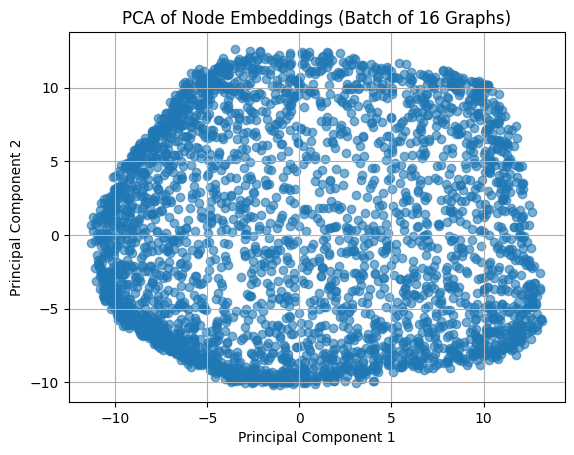

In [5]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

cpu_embeddings = embeddings3.clone().cpu()
# Step 1: Flatten across batch and node dimensions
flat_embeddings = cpu_embeddings.reshape(-1, cpu_embeddings.shape[-1])  # shape: (160, 128)

# Step 2: Apply PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(flat_embeddings)

# Step 3: Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

# Step 4: (Optional) Visualization
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.6)
plt.title('PCA of Node Embeddings (Batch of 16 Graphs)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


torch.Size([200, 128])
Explained variance ratio: [0.24653569 0.21383617]
Total explained variance: 0.4603718582571285


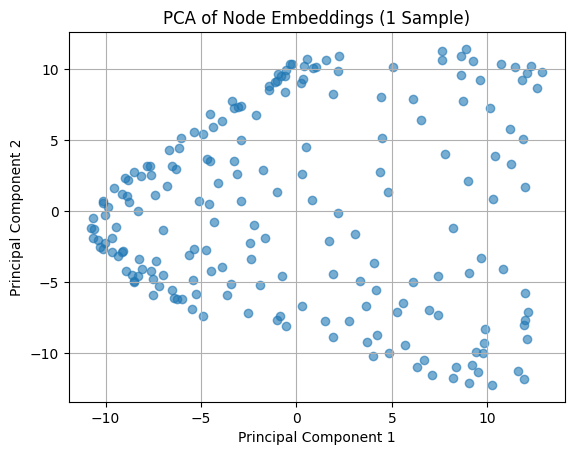

In [6]:
single_sample = embeddings3[0,:, :]
print(single_sample.shape)

cpu_embeddings = single_sample.clone().cpu()
# Step 1: Flatten across batch and node dimensions

# Step 2: Apply PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(cpu_embeddings)

# Step 3: Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

# Step 4: (Optional) Visualization
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.6)
plt.title('PCA of Node Embeddings (1 Sample)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


In [5]:
import numpy as np
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.io as pio

# Optional: Set default renderer (you can choose 'notebook', 'browser', etc.)
pio.renderers.default = 'browser'  # Change to 'notebook' if you're using Jupyter

# ==== INPUT: Your embedding tensor ====
# embeddings shape: (batch_size=16, num_nodes=10, embedding_dim=128)
# Replace this with your actual model output
# embeddings = model_output  # shape (16, 10, 128)

# ---- Step 1: Flatten batch and node dimensions ----
flat_embeddings = embeddings3.reshape(-1, embeddings3.shape[-1])  # shape: (160, 128)

# Also store metadata for each embedding (e.g., graph index, node index)
batch_size, num_nodes = embeddings3.shape[0], embeddings3.shape[1]
graph_ids = np.repeat(np.arange(batch_size), num_nodes)
node_ids = np.tile(np.arange(num_nodes), batch_size)

# ---- Step 2: PCA to 3D ----
pca_3d = PCA(n_components=3)
reduced_3d = pca_3d.fit_transform(flat_embeddings)
explained_3d = np.sum(pca_3d.explained_variance_ratio_)
print("3D PCA explained variance:", explained_3d)

# ---- Step 3: PCA to 4D ----
pca_4d = PCA(n_components=4)
reduced_4d = pca_4d.fit_transform(flat_embeddings)
explained_4d = np.sum(pca_4d.explained_variance_ratio_)
print("4D PCA explained variance:", explained_4d)

# =======================
# 📊 PLOTLY: 3D Scatter Plot
# =======================
fig3d = px.scatter_3d(
    x=reduced_3d[:, 0],
    y=reduced_3d[:, 1],
    z=reduced_3d[:, 2],
    color=graph_ids.astype(str),  # Color by graph
    title=f'3D PCA of Node Embeddings (Explained Variance: {explained_3d:.2%})',
    labels={'color': 'Graph ID'},
    opacity=0.8
)
fig3d.show()

# =======================
# 📊 PLOTLY: 4D Visualization (Color as 4th dimension)
# =======================
# We'll plot first 3 components, and encode 4th as color
fig4d = px.scatter_3d(
    x=reduced_4d[:, 0],
    y=reduced_4d[:, 1],
    z=reduced_4d[:, 2],
    color=reduced_4d[:, 3],  # Use 4th component as color
    title=f'4D PCA (color = 4th PC) (Explained Variance: {explained_4d:.2%})',
    labels={'color': 'PC4'},
    opacity=0.8
)
fig4d.show()


3D PCA explained variance: 0.5834491928636018
4D PCA explained variance: 0.6936083296329099


In [9]:
import numpy as np
from sklearn.decomposition import PCA

# Assume `embeddings` is your model output of shape (16, 10, 128)
# Replace this with your actual tensor
# embeddings = model_output

# Flatten batch and node dimensions → shape: (160, 128)
flat_embeddings = embeddings3.reshape(-1, embeddings3.shape[-1])

# ---- 5D PCA ----
pca_5d = PCA(n_components=5)
reduced_5d = pca_5d.fit_transform(flat_embeddings)
explained_5d = np.sum(pca_5d.explained_variance_ratio_)
print("5D PCA explained variance:", explained_5d)
print("5D PCA explained variance ratio per component:", pca_5d.explained_variance_ratio_)

# ---- 6D PCA ----
pca_6d = PCA(n_components=6)
reduced_6d = pca_6d.fit_transform(flat_embeddings)
explained_6d = np.sum(pca_6d.explained_variance_ratio_)
print("6D PCA explained variance:", explained_6d)
print("6D PCA explained variance ratio per component:", pca_6d.explained_variance_ratio_)

# ---- 7D PCA ----
pca_7d = PCA(n_components=7)
reduced_7d = pca_7d.fit_transform(flat_embeddings)
explained_7d = np.sum(pca_7d.explained_variance_ratio_)
print("7D PCA explained variance:", explained_7d)
print("7D PCA explained variance ratio per component:", pca_7d.explained_variance_ratio_)

# ---- 8D PCA ----
pca_8d = PCA(n_components=8)
reduced_8d = pca_8d.fit_transform(flat_embeddings)
explained_8d = np.sum(pca_8d.explained_variance_ratio_)
print("8D PCA explained variance:", explained_8d)
print("8D PCA explained variance ratio per component:", pca_8d.explained_variance_ratio_)

# ---- 9D PCA ----
pca_9d = PCA(n_components=9)
reduced_9d = pca_9d.fit_transform(flat_embeddings)
explained_9d = np.sum(pca_9d.explained_variance_ratio_)
print("9D PCA explained variance:", explained_9d)
print("9D PCA explained variance ratio per component:", pca_9d.explained_variance_ratio_)

# ---- 10D PCA ----
pca_10d = PCA(n_components=10)
reduced_10d = pca_10d.fit_transform(flat_embeddings)
explained_10d = np.sum(pca_10d.explained_variance_ratio_)
print("10D PCA explained variance:", explained_10d)
print("10D PCA explained variance ratio per component:", pca_10d.explained_variance_ratio_)


5D PCA explained variance: 0.7730994528982202
5D PCA explained variance ratio per component: [0.242312   0.21803018 0.12310702 0.11015914 0.07949112]
6D PCA explained variance: 0.8109596362309158
6D PCA explained variance ratio per component: [0.242312   0.21803018 0.12310702 0.11015914 0.07949112 0.03786018]
7D PCA explained variance: 0.8413912134369326
7D PCA explained variance ratio per component: [0.242312   0.21803018 0.12310702 0.11015914 0.07949112 0.03786018
 0.03043158]
8D PCA explained variance: 0.8663734877784635
8D PCA explained variance ratio per component: [0.242312   0.21803018 0.12310702 0.11015914 0.07949112 0.03786018
 0.03043158 0.02498227]
9D PCA explained variance: 0.8902222708914419
9D PCA explained variance ratio per component: [0.242312   0.21803018 0.12310702 0.11015914 0.07949112 0.03786018
 0.03043158 0.02498227 0.02384878]
10D PCA explained variance: 0.9092277435645019
10D PCA explained variance ratio per component: [0.242312   0.21803018 0.12310702 0.110159